<a href="https://colab.research.google.com/github/mikachan400/carisurg-portfolio-week-0/blob/main/Week0_Tutorial3_Visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CariSurg MedTech Pathways — Week 0, Tutorial 3
## Day 3 Submission: Basic Data Visualisation with matplotlib
**Student Portfolio:** Day 3 Deliverable  
**Clinical Focus:** Mercer General Hospital ED Triage Dataset

This notebook creates clinically meaningful visualisations from our cleaned triage dataset.
Per the program guidelines, every plot answers a specific clinical question to help healthcare staff interpret patient states quickly.

## Step 1. System Setup, Data Loading & Cleaning
**Mount your Google Drive, load the dirty dataset, and apply all cleaning rules:**

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'

# Mount your Google Drive so files are accessible from Colab
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")

# Define the file path
FILE_PATH = '/content/drive/MyDrive/ColabNotebooks/EmergencyTriageDataset_Reduced_Dirty.csv'
df = pd.read_csv(FILE_PATH)

# Data load verification
print("--- INITIAL DIRTY DATASET STRUCTURE ---")
df.info()
print("\n--- INITIAL DIRTY DATASET ROWS ---")
print(df.head()) # Wrapped in print() so it forces Colab to show it in the middle of execution

# ─── APPLY ALL CLINICAL CLEANING PIPELINES ───

# Gender Standardization
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

# Glasgow Coma Scale (GCS) Cleaning
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
df['GCS'] = df['GCS'].fillna(df['GCS'].median())

# Systolic Blood Pressure (SBP) Cleaning
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
df['SBP'] = df['SBP'].fillna(df['SBP'].median())

# Diastolic Blood Pressure (DBP) Cleaning
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
df.loc[(df['DBP'] < 30) | (df['DBP'] > 150), 'DBP'] = np.nan
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

# Pulse / Heart Rate Cleaning
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
df.loc[(df['pulse'] < 20) | (df['pulse'] > 250), 'pulse'] = np.nan
df['pulse'] = df['pulse'].fillna(df['pulse'].median())

# Temperature Cleaning (Standardizing F to C)
def to_celsius(val):
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df['Temp'] = df['Temp'].apply(to_celsius)
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan
df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# Respiratory Rate (RR) Cleaning
df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
df.loc[(df['RR'] < 5) | (df['RR'] > 60), 'RR'] = np.nan
df['RR'] = df['RR'].fillna(df['RR'].median())

# Fraction of Inspired Oxygen (FiO2) Cleaning
df['Fio2'] = pd.to_numeric(df['Fio2'], errors='coerce')
df['Fio2'] = df['Fio2'].fillna(df['Fio2'].median())

# Mean Arterial Pressure (MAP) Backfill Calculation
df['MAP'] = pd.to_numeric(df['MAP'], errors='coerce')
df['MAP_Calc'] = (df['SBP'] + 2 * df['DBP']) / 3
df['MAP'] = df['MAP'].fillna(df['MAP_Calc'])
df = df.drop(columns=['MAP_Calc'])

print("\n" + "="*40)
print(f"Success! Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total NaNs remaining: {df.isnull().sum().sum()}")
print("="*40)
df.info()
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully!
--- INITIAL DIRTY DATASET STRUCTURE ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      2205 non-null   int64  
 1   Age     2205 non-null   int64  
 2   Gender  2205 non-null   object 
 3   GCS     2183 non-null   object 
 4   SBP     2205 non-null   object 
 5   DBP     2183 non-null   float64
 6   MAP     2183 non-null   float64
 7   pulse   2183 non-null   object 
 8   Temp    2183 non-null   object 
 9   RR      2183 non-null   float64
 10  Fio2    2183 non-null   float64
dtypes: float64(4), int64(2), object(5)
memory usage: 189.6+ KB

--- INITIAL DIRTY DATASET ROWS ---
   ID  Age  Gender   GCS  SBP    DBP     MAP  pulse  Temp    RR   Fio2
0   1   34       0  15.0   93   67.0   75.67

,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0


Deliverable 1 — The Histogram (Temperature & Sepsis Screening)

**Satisfies the clinical question requirement and maps out key diagnostic thresholds:**

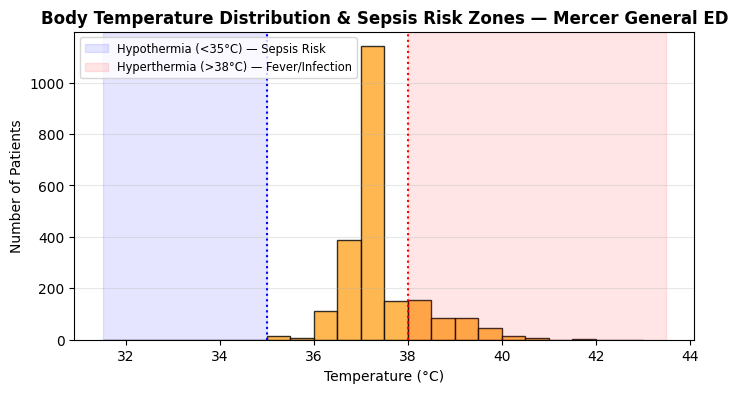

Saved: temperature_sepsis_histogram.png


In [16]:
# 1. What is the clinical question this plot answers?
# Answer: How are body temperatures distributed across the triage cohort? Do we observe
# significant clusters of hyperthermia (>38°C) or hypothermia (<35°C) that would
# automatically trigger emergency sepsis screening protocols at Mercer General?

# 2. What type of plot is appropriate?
# Answer: A histogram, because we need to see the frequency distribution and spread
# of a single continuous clinical variable (Temperature).

# 3. What reference lines or annotations would add clinical meaning?
# Answer: A vertical line at 38.0°C to mark the diagnostic threshold for pyrexia (fever),
# and a vertical line at 36.0°C to mark the threshold for hypothermia.

plt.figure(figsize=(8, 4))

# Create the histogram (Temps are continuous, 0.5°C bins give a clean clinical view)
plt.hist(df['Temp'], bins=np.arange(31.5, 43.5, 0.5), edgecolor='black', color='#FFA726', alpha=0.8)

# Add critical clinical reference zones
# Hypothermia zone (<35°C)
plt.axvspan(31.5, 35, alpha=0.1, color='blue', label='Hypothermia (<35°C) — Sepsis Risk')
plt.axvline(x=35, color='blue', linestyle=':', linewidth=1.5)

# Hyperthermia/Fever zone (>38°C)
plt.axvspan(38, 43.5, alpha=0.1, color='red', label='Hyperthermia (>38°C) — Fever/Infection')
plt.axvline(x=38, color='red', linestyle=':', linewidth=1.5)

# Plot labeling & styling
plt.title('Body Temperature Distribution & Sepsis Risk Zones — Mercer General ED', fontsize=12, fontweight='bold')
plt.xlabel('Temperature (°C)', fontsize=10)
plt.ylabel('Number of Patients', fontsize=10)
plt.legend(fontsize=8.3, loc='upper left')
plt.grid(axis='y', alpha=0.3)

# Save the file cleanly for deployment portfolio
plt.savefig('temperature_sepsis_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: temperature_sepsis_histogram.png")

# Clinical Observation Summary:
# The temperature distribution tightly clusters around the normal human physiological mean
# of 36.5°C to 37.3°C. Crucially, the visual highlights outliers falling into the critical
# red and blue zones, allowing clinical teams to spot patients requiring urgent intervention.

Deliverable 2 - Pulse vs. MAP Scatter Plot

 **Pairs Mean Arterial Pressure (perfusion) against Heart Rate to visually highlight patients entering clinical shock:**

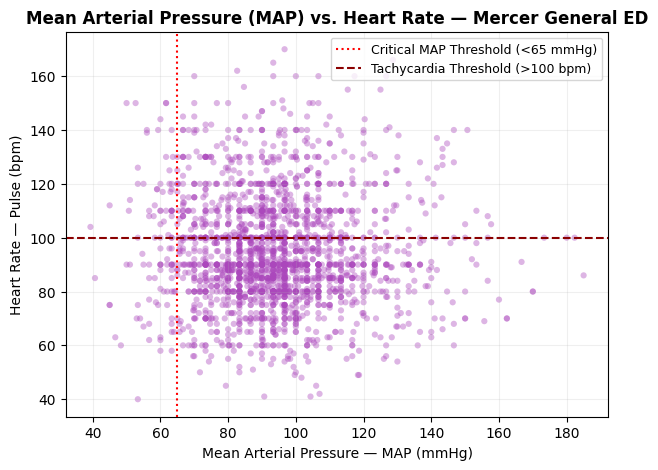

Saved: map_vs_pulse_scatter.png


In [8]:
# 1. What is the clinical question this plot answers?
# Answer: Is there an observable relationship between a patient's Mean Arterial Pressure (MAP)
# and their heart rate (pulse)? Specifically, do patients exhibiting signs of hemodynamic
# shock (MAP < 65 mmHg) present with compensatory tachycardia (>100 bpm) to sustain cardiac output?

# 2. What type of plot is appropriate?
# Answer: A scatter plot, because we are analyzing the physiological correlation and
# interaction between two distinct numeric vital signs (MAP and Pulse).

# 3. What reference lines or annotations would add clinical meaning?
# Answer: A vertical reference line at MAP = 65 mmHg to isolate the organ hypoperfusion/shock threshold,
# and a horizontal reference line at Pulse = 100 bpm to mark the onset of tachycardia.

plt.figure(figsize=(7, 5))
plt.scatter(df['MAP'], df['pulse'], alpha=0.4, s=20, color='#AB47BC', edgecolors='none')

# Visual clinical reference bounds
plt.axvline(x=65, color='red', linestyle=':', linewidth=1.5, label='Critical MAP Threshold (<65 mmHg)')
plt.axhline(y=100, color='darkred', linestyle='--', linewidth=1.5, label='Tachycardia Threshold (>100 bpm)')

plt.title('Mean Arterial Pressure (MAP) vs. Heart Rate — Mercer General ED', fontsize=12, fontweight='bold')
plt.xlabel('Mean Arterial Pressure — MAP (mmHg)', fontsize=10)
plt.ylabel('Heart Rate — Pulse (bpm)', fontsize=10)
plt.legend(fontsize=9, loc='upper right')
plt.grid(True, alpha=0.2)

plt.savefig('map_vs_pulse_scatter.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: map_vs_pulse_scatter.png")

#------                             SUMMARY                                     ------
# These visualizations help confirm that the cleaned dataset is clinically reasonable
# and allow quick identification of unstable patterns, such as sepsis and shock, in patient vital signs.

In [12]:
# Summary: all the plots we created today
import os
plot_files = [f for f in os.listdir('.') if f.endswith('.png')]
print("Plots saved in this session:")
for f in sorted(plot_files):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f:35s} ({size_kb:.0f} KB)")

Plots saved in this session:
  map_vs_pulse_scatter.png            (125 KB)
  temperature_sepsis_histogram.png    (38 KB)
